In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving cleaned_april_weather.csv to cleaned_april_weather.csv
Saving cleaned_june_weather.csv to cleaned_june_weather.csv
Saving cleaned_march_weather.csv to cleaned_march_weather.csv
Saving cleaned_may_weather.csv to cleaned_may_weather.csv
Saving cleaned_panel_data_ps (1).csv to cleaned_panel_data_ps (1).csv
Saving Soiling(march_july).csv to Soiling(march_july).csv


In [ ]:
march = pd.read_csv("cleaned_march_weather.csv")
april = pd.read_csv("cleaned_april_weather.csv")
may = pd.read_csv("cleaned_may_weather.csv")
june = pd.read_csv("cleaned_june_weather.csv")

In [ ]:
weather = pd.concat([march, april, may, june], ignore_index=True)
weather['Datetime'] = pd.to_datetime(
    weather['Datetime'],
    format='mixed',
    dayfirst=True
)


# Sort properly
weather = weather.sort_values('Datetime')

In [ ]:
weather_0 = weather.copy()
weather_0['Panel_State'] = 0

weather_1 = weather.copy()
weather_1['Panel_State'] = 1

In [ ]:
weather_expanded = pd.concat([weather_0, weather_1], ignore_index=True)

weather_expanded = weather_expanded.sort_values(['Datetime', 'Panel_State']).reset_index(drop=True)

In [ ]:
weather_expanded.head()

,Datetime,Outdoor Temperature (°C),Feels Like (°C),Dew Point (°C),Wind Speed (m/sec),Wind Gust (m/sec),Max Daily Gust (m/sec),Wind Direction (°),Hourly Rain (mm/hr),Event Rain (mm),...,Weekly Rain (mm),Monthly Rain (mm),Yearly Rain (mm),Humidity (%),Ultra-Violet Radiation Index,Solar Radiation (W/m^2),Outdoor Battery,Avg Wind Direction (10 mins) (°),Avg Wind Speed (10 mins) (m/sec),Panel_State
0,2023-03-01 00:00:00,23.88,24.57,21.23,0.25,0.58,0.75,242.25,0.0,0.0,...,0.0,0.0,1063.6,85.25,0.0,0.0,1.0,244.42,0.25,0
1,2023-03-01 00:00:00,23.88,24.57,21.23,0.25,0.58,0.75,242.25,0.0,0.0,...,0.0,0.0,1063.6,85.25,0.0,0.0,1.0,244.42,0.25,1
2,2023-03-01 01:00:00,23.71,24.41,21.28,0.03,0.29,1.00,211.83,0.0,0.0,...,0.0,0.0,1063.6,86.33,0.0,0.0,1.0,220.58,0.08,0
3,2023-03-01 01:00:00,23.71,24.41,21.28,0.03,0.29,1.00,211.83,0.0,0.0,...,0.0,0.0,1063.6,86.33,0.0,0.0,1.0,220.58,0.08,1
4,2023-03-01 02:00:00,23.62,24.32,21.38,0.03,0.21,1.00,182.17,0.0,0.0,...,0.0,0.0,1063.6,87.25,0.0,0.0,1.0,184.00,0.00,0


In [ ]:
panel = pd.read_csv("cleaned_panel_data_ps (1).csv")

panel['Datetime'] = pd.to_datetime(
    panel['Datetime'],
    format='mixed',
    dayfirst=True
)

panel = panel.sort_values('Datetime')


In [ ]:
len(weather_expanded)

5952

In [ ]:
len(panel)

3058

In [ ]:
panel = panel.drop_duplicates()


In [ ]:
merged = pd.merge(
    weather_expanded,
    panel,
    on=['Datetime', 'Panel_State'],
    how='left'
)


In [ ]:
merged.to_csv("final_merged_weather_panel.csv", index=False)


In [ ]:
files.download("final_merged_weather_panel.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **VOLTAGE AND CURRENT PREDICTION**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving merged_weather_panel_01.csv to merged_weather_panel_01.csv


In [ ]:
df = pd.read_csv("merged_weather_panel_01.csv")

df['Datetime'] = pd.to_datetime(df['Datetime'], format='mixed', dayfirst=True)
df = df.sort_values('Datetime')


In [ ]:
SOLAR_THRESHOLD =50
night_mask = df['Solar Radiation (W/m^2)'] <= SOLAR_THRESHOLD

df.loc[night_mask, 'Current'] = 0
df.loc[night_mask, 'Voltage'] = 0
df.loc[night_mask, 'Power'] = 0


In [ ]:
df_day = df[df['Solar Radiation (W/m^2)'] > SOLAR_THRESHOLD].copy()


In [ ]:
df_day['Solar_Temp_Interaction'] = (
    df_day['Solar Radiation (W/m^2)'] *
    df_day['Outdoor Temperature (°C)']
)


In [ ]:
clean_df = df_day[df_day['Panel_State'] == 0].copy()
soiled_df = df_day[df_day['Panel_State'] == 1].copy()


In [ ]:
feature_cols = [
    'Solar Radiation (W/m^2)',
    'Outdoor Temperature (°C)',
    'Wind Speed (m/sec)',
    'Humidity (%)',
    'Solar_Temp_Interaction'
]


In [ ]:


def train_rf_model(data, target_col, label_name):

    data = data.dropna(subset=[target_col])

    X = data[feature_cols]
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n--- {label_name} {target_col} Model ---")
    print("R²:", r2)
    print("RMSE:", rmse)
    print("MAE:", mae)

    return rf


In [ ]:
clean_voltage_model = train_rf_model(clean_df, 'Voltage', 'Clean')
clean_power_model = train_rf_model(clean_df, 'Power', 'Clean')
soiled_voltage_model = train_rf_model(soiled_df, 'Voltage', 'Soiled')
soiled_power_model = train_rf_model(soiled_df, 'Power', 'Soiled')



--- Clean Voltage Model ---
R²: 0.8849895506063381
RMSE: 1.4249056811975434
MAE: 0.703914040755155

--- Clean Power Model ---
R²: 0.22990994917144947
RMSE: 48.28176093085238
MAE: 20.527291148489393

--- Soiled Voltage Model ---
R²: 0.5831489463076941
RMSE: 3.8792654944634304
MAE: 1.8420892615768418

--- Soiled Power Model ---
R²: 0.1643765265105589
RMSE: 265.7217206217809
MAE: 100.60285341205541


In [ ]:
df[['Voltage','Current','Power']].describe()


,Voltage,Current,Power
count,5038.000000,5038.000000,5038.000000
mean,5.806574,0.925381,20.175580
std,8.522353,3.063577,111.404578
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,17.401973,1.950642,34.535285
max,44.344504,42.357498,1878.322206


In [ ]:
def fill_missing_power_based(data, voltage_model, power_model):

    # Find missing rows
    missing_mask = (
        data['Voltage'].isna() |
        data['Power'].isna() |
        data['Current'].isna()
    )

    if missing_mask.sum() == 0:
        return data

    X_missing = data.loc[missing_mask, feature_cols]

    # Predict
    voltage_pred = voltage_model.predict(X_missing)
    power_pred = power_model.predict(X_missing)

    # Physical constraints
    voltage_pred = np.clip(voltage_pred, 0, 50)
    power_pred = np.maximum(power_pred, 0)

    # Compute Current
    current_pred = np.divide(
        power_pred,
        voltage_pred,
        out=np.zeros_like(power_pred),
        where=voltage_pred != 0
    )

    # Assign back
    data.loc[missing_mask, 'Voltage'] = voltage_pred
    data.loc[missing_mask, 'Power'] = power_pred
    data.loc[missing_mask, 'Current'] = current_pred

    return data


In [ ]:
clean_df = fill_missing_power_based(
    clean_df,
    clean_voltage_model,
    clean_power_model
)

soiled_df = fill_missing_power_based(
    soiled_df,
    soiled_voltage_model,
    soiled_power_model
)


In [ ]:
df_day_filled = pd.concat([clean_df, soiled_df])

df.update(df_day_filled)


In [ ]:
df['Current'] = np.divide(
    df['Power'],
    df['Voltage'],
    out=np.zeros_like(df['Power']),
    where=df['Voltage'] != 0
)


In [ ]:
night_mask = df['Solar Radiation (W/m^2)'] <= SOLAR_THRESHOLD

df.loc[night_mask, 'Voltage'] = 0
df.loc[night_mask, 'Current'] = 0
df.loc[night_mask, 'Power'] = 0


In [ ]:
cols = [col for col in df.columns if col != 'Panel_State'] + ['Panel_State']
df = df[cols]


In [ ]:
df = df.sort_values(by=['Datetime', 'Panel_State']).reset_index(drop=True)


In [ ]:
# Create mask
day_mask = df['Solar Radiation (W/m^2)'] > SOLAR_THRESHOLD

# Apply smoothing only to daylight rows
df.loc[day_mask, 'Current'] = (
    df[day_mask]
    .groupby('Panel_State')['Current']
    .transform(lambda x: x.rolling(window=3, center=True, min_periods=1).mean())
)


In [ ]:
print(df[['Voltage','Current','Power']].isna().sum())


Voltage    0
Current    0
Power      0
dtype: int64


In [ ]:
df.to_csv("merged_weather_panel_ml.csv", index=False)


In [ ]:
files.download("merged_weather_panel_ml.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

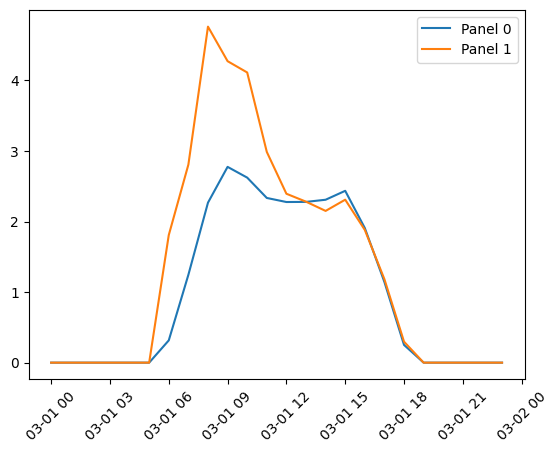

In [ ]:
one_day = df[df['Datetime'].dt.date == pd.to_datetime("2023-03-01").date()]

import matplotlib.pyplot as plt

plt.plot(one_day[one_day['Panel_State']==0]['Datetime'],
         one_day[one_day['Panel_State']==0]['Current'],
         label="Panel 0")

plt.plot(one_day[one_day['Panel_State']==1]['Datetime'],
         one_day[one_day['Panel_State']==1]['Current'],
         label="Panel 1")

plt.legend()
plt.xticks(rotation=45)
plt.show()


In [ ]:
Datetime     2023-03-01  2023-03-02  2023-03-03  2023-03-04  2023-03-05  \
Panel_State
0            407.986922  414.693412  423.249650  443.019533  468.080994
1            524.991529  523.855815  707.999589  799.031557  860.364574

Datetime      2023-03-06  2023-03-07  2023-03-08  2023-03-09  2023-03-10  ...  \
Panel_State                                                               ...
0             462.352719  401.652570  416.427415  379.364938  362.894689  ...
1            1054.850395  633.712834  628.544078  572.161756  374.672684  ...

Datetime     2023-06-21  2023-06-22  2023-06-23  2023-06-24  2023-06-25  \
Panel_State
0            337.715354  291.755467  461.353740  437.242176  475.827569
1            441.316005  425.503300  740.849446  808.935814  973.709497

Datetime     2023-06-26  2023-06-27  2023-06-28  2023-06-29  2023-06-30
Panel_State
0            387.948613  398.929962  483.386791  505.000932  481.942082
1            835.802562  415.677779  920.239316  970.168036  990.083626


SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (ipython-input-36640459.py, line 1)